# IMPORT

In [15]:
import os
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib as mpl 
import numpy as np
from matplotlib import rc
import matplotlib.font_manager as fm
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch

## Colab 환경에서 실행 시 환경 설정

In [16]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

#### 코랩에서 한국어 표시하기

In [ ]:
!apt-get install fonts-nanum* -qq
# 다운받은 후 코랩 런타임 다시 시작

In [ ]:
%matplotlib inline
# 별도의 plt.show()를 호출하지 않아도 그래프가 노트북 내부에 자동으로 출력됨
import matplotlib.pyplot as plt
import matplotlib as mpl 

plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 패치
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = mpl.font_manager.FontProperties(fname=path).get_name()
plt.rcParams['font.family'] = font_name

In [ ]:
import numpy as np
from matplotlib import rc
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시스템에서 사용할 수 있는 한글 폰트 확인
for font in fm.findSystemFonts():
    if 'Nanum' in font or 'Malgun' in font or 'AppleGothic' in font:
        print(font)

# 한글 폰트 경로 설정 
import platform
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')  # Windows의 기본 한글 폰트 (맑은 고딕)
elif platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')  # macOS의 기본 한글 폰트 (애플 고딕)
else:  # Linux
    rc('font', family='NanumGothic')  # Linux에서는 나눔고딕을 사용 (설치 필요)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.titlepad'] = 10

# 🔖 CNN 모델 학습 및 다양한 이미지 분류 모델

<a id="lecture_index"></a>
## 수업 목차 

[1. 합성곱 신경망 복습 및 CIFAR-10 데이터 셋을 활용한 분류 모델 만들기](#one)<br>
- 목요일 내용 복습 
- 이미지 데이터셋 구조 이해
- CIFAR-10 데이터 셋을 활용한 분류 모델 만들기

[2. DataLoader 및 데이터 전처리](#two)<br>
- 이미지 폴더 구조에 따라 DataLoader 만들기 
- Dataset, DataLoader 사용 이유
- Resize, ToTensor, Normalize 개념과 시각적 비교
- Quiz1

[3. CNN 모델 성능 개선하기](#three)<br>
- Augmentation (RandomFlip, RandomCrop, ColorJitter 등)
- Dropout, BatchNorm 적용 실습
- EarlyStopping & Checkpoint 활용하기
 
[4. 다양한 이미지 분류 모델](#four)<br>
- CNN이 어떻게 발전했는가 (LeNet → AlexNet → VGG 간략 흐름)
- AlexNet 구조 분석 및 PyTorch 구현하기
- VGG 구조 분석 및 PyTorch 구현하기 
- Quiz2
- 사전학습 모델 

[5. 실습](#five)<br>

## <a id='one'>1️⃣ 합성곱 신경망 복습 및 CIFAR-10 데이터 셋을 활용한 분류 모델 만들기</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 목요일 내용 복습

> CNN(합성곱 신경망)은 이미지와 같이 공간적 구조를 가진 데이터를 효과적으로 처리하기 위한 딥러닝 모델입니다. <br>
> 주요 구성 요소: 합성곱(Convolution), 풀링(Pooling), 활성화 함수(ReLU), 완전 연결층(FC)

```
핵심 용어 정리
• 채널 (Channel): 컬러 이미지의 경우 3채널 (RGB)
• 커널 / 필터: 이미지의 특징을 추출하는 작은 창
• 합성곱 연산: 커널을 이미지에 슬라이딩하며 특징 추출
• 스트라이드 / 패딩: 커널 이동 간격 및 테두리 처리
• 풀링(Pooling): 다운샘플링으로 계산량 및 과적합 줄이기
```

## CIFAR-10 데이터 셋을 활용한 분류 모델 만들기

In [ ]:
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 0에서 1 사이로 정규화 0 ~ 255 / numpy array -> Tensor 데이터로 변환
    transforms.Resize((32, 32)),    # reshape는 사이즈를 유지하면서 변경, resize는 사이즈에 맞게 해상도를 줄이면서 변형
])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = CIFAR10(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

In [ ]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
           )

In [ ]:
testset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
           )

In [ ]:
img, label = next(iter(trainloader))

In [ ]:
img.dtype, label.dtype

(torch.float32, torch.int64)

In [ ]:
img.shape, label.shape

(torch.Size([32, 3, 32, 32]), torch.Size([32]))

In [ ]:
image = img[0].permute(1, 2 ,0).numpy()


In [ ]:
type(image)

numpy.ndarray

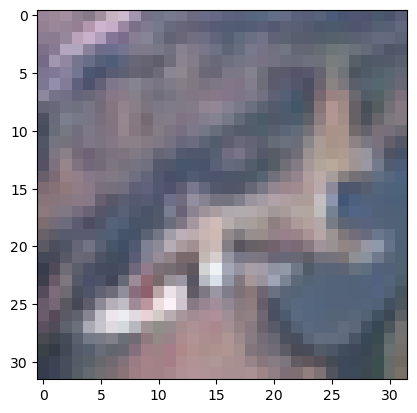

In [ ]:
import os    
os.environ['KMP_DUPLICATE_LIB_OK']='True'

plt.imshow(image)

In [ ]:
import torch.nn as nn

class MyCNN_avg(nn.Module): # 딥러닝 모델을 작동할 수 있도록 설계된 클래스
    def __init__(self):
        super(MyCNN_avg, self).__init__()   # super: 부모, self: 인스턴스
                        # 학습을 하면서 생기는 가중치에 대한 OrderDict 데이터 자료형, layer에 대한 정보, 미분값을 저장하는 기능
        
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride = 1, padding=1) # padding = 0 / (32 * 32)
        self.pool1 = nn.AvgPool2d(2, 2) # kernel_size, stride (16 * 16)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1) # 14 * 14  / avg fool을 하면 남는건 버려짐
        self.pool2 = nn.AvgPool2d(2, 2) # (7 * 7)
        self.relu = nn.ReLU()
        
        # self.sigmoid = nn.Sigmoid()
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 7 * 7, 120)
        self.fc2 = nn.Linear(120, 10)
        
    def forward(self, x): # 순전파
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        # x = self.sigmoid(x)
        
        return x         

In [ ]:
import torch.nn as nn

class MyCNN_max(nn.Module): # 딥러닝 모델을 작동할 수 있도록 설계된 클래스
    def __init__(self):
        super(MyCNN_max, self).__init__()   # super: 부모, self: 인스턴스
                        # 학습을 하면서 생기는 가중치에 대한 OrderDict 데이터 자료형, layer에 대한 정보, 미분값을 저장하는 기능
        
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride = 1, padding=1) # padding = 0 / (32 * 32)
        self.pool1 = nn.MaxPool2d(2, 2) # kernel_size, stride (15 * 15)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1) # 13 * 13
        self.pool2 = nn.MaxPool2d(2, 2) # (6 * 6)
        self.relu = nn.ReLU()
        
        # self.sigmoid = nn.Sigmoid()
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 7 * 7, 120)
        self.fc2 = nn.Linear(120, 10)
        
    def forward(self, x): # 순전파
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        # x = self.sigmoid(x)
        
        return x         

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
device

device(type='cpu')

In [ ]:
model_avg = MyCNN_avg()
model_max = MyCNN_max()

In [ ]:
model_avg.parameters()

<generator object Module.parameters at 0x0000020BB363FB50>

In [ ]:
loss_fn = nn.CrossEntropyLoss() # 각 데이터별 특화된 모델의 loss function 적용
optimizer = torch.optim.Adam(model_avg.parameters(), lr=0.001)   # 파라미터, 학습률 / 이미지일떄는 학습률을 0.001부터터

In [ ]:
loss_fn = nn.CrossEntropyLoss() # 각 데이터별 특화된 모델의 loss function 적용
optimizer = torch.optim.Adam(model_max.parameters(), lr=0.001)   # 파라미터, 학습률 / 이미지일떄는 학습률을 0.001부터터

In [ ]:
def train_model(model, loss_fn, optimizer, dataloader, epoch = 10):
    model.to(device)
    model.train()
    
    train_losses = []
    
    for ep in range(epoch):
        total_loss = 0
        total_batch = 0
        for image, label in dataloader:
            image, label = image.to(device), label.to(device)   # gpu 연산을 위한 이동
            
            optimizer.zero_grad()   # 가중치 초기화
            pred = model(image) # 예측값
            # print(pred.shape, label.shape)
            loss = loss_fn(pred, label) # Cross Entropy losss는 확룰값을 받음
            
            loss.backward() # 역전파 (미분값 구하기)
            optimizer.step() # 가중치 업데이트
            
            total_batch += image.size(0)
            total_loss += loss.item() # 배치단위의 loss
        
        print(f"Epoch: {ep}, Train Loss: {total_loss/total_batch}")
        train_losses.append(total_loss / total_batch) # epoch당 loss
            

In [ ]:
train_model(dataloader=trainloader, model= model_avg, loss_fn=loss_fn, optimizer=optimizer)

Epoch: 0, Train Loss: 0.049797600001096724
Epoch: 1, Train Loss: 0.041176643724441526
Epoch: 2, Train Loss: 0.03760249664068222
Epoch: 3, Train Loss: 0.035124383298158646
Epoch: 4, Train Loss: 0.03335770531892777
Epoch: 5, Train Loss: 0.03209571041285992
Epoch: 6, Train Loss: 0.03127519856572151
Epoch: 7, Train Loss: 0.030574101493358614
Epoch: 8, Train Loss: 0.02998256375670433
Epoch: 9, Train Loss: 0.02946256699860096


In [ ]:
train_model(dataloader=trainloader, model= model_max, loss_fn=loss_fn, optimizer=optimizer)

Epoch: 0, Train Loss: 0.04585101908802986
Epoch: 1, Train Loss: 0.03658878720760345
Epoch: 2, Train Loss: 0.03313114384055137
Epoch: 3, Train Loss: 0.031001798865795134
Epoch: 4, Train Loss: 0.029499275302886964
Epoch: 5, Train Loss: 0.028479112422466278
Epoch: 6, Train Loss: 0.027505241345763206
Epoch: 7, Train Loss: 0.02661280232667923
Epoch: 8, Train Loss: 0.02599476715385914
Epoch: 9, Train Loss: 0.025483256130218505


In [ ]:
for img, label in testloader:
    y_pred = model_avg(img)
    _, predicted = torch.max(y_pred, 1)
    print(predicted)
    # accuracy = (predicted == label).float().mean().item()

# print(f"Accuracy: {accuracy}")

Accuracy: 0.5


In [ ]:
images, labels = next(iter(testloader))

In [ ]:
model_avg.eval()
model_avg.to(device)

with torch.no_grad():
    image = images[0].unsqueeze(0).to(device)
    pred = model_avg(image)
    
    _, predicted = torch.max(pred, 1)
    print(predicted)

tensor([8])


In [ ]:
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

In [ ]:
test_accuracy = evaluate_model(model_max, testloader)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 68.57%


In [ ]:
target_labels = {v: k for k, v in trainloader.class_to_idx.items()}

def visualize_predictions(model, test_loader):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images[:20].to(device), labels[:20].to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
    
    images = images.cpu().numpy()
    
    fig, axes = plt.subplots(4, 5, figsize=(10, 5))  # axes: 2x5의 subplot을 가지는 figure 생성
    for i, ax in enumerate(axes.flat): # axes.flat: 1차원으로 평평하게 만들어주는 함수 -> 10개의 subplot을 순차적으로 접근 가능
        img = images[i].squeeze()
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {target_labels[labels[i].item()]}\nPred: {target_labels[predicted[i].item()]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

AttributeError: 'DataLoader' object has no attribute 'class_to_idx'

## <a id='two'>2️⃣ 데이터 전처리 및 DataLoader</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 이미지 폴더 구조에 따라 DataLoader 만들기

> PyTorch는 torchvision.datasets.ImageFolder를 통해 폴더 구조 기반 이미지 분류 데이터셋을 쉽게 불러올 수 있다

### train / val 데이터 셋으로 나누어진 경우

```bash
dataset1/
  train/
    cats/
      cat001.jpg
      ...
    dogs/
      dog001.jpg
      ...
  val/
    cats/
      cat001.jpg
      ...
    dogs/
      dog001.jpg
      ...
```

### train/val 폴더로 나누어져 있지 않은 경우

```bash
dataset2/
    cats/
      cat001.jpg
      ...
    dogs/
      dog001.jpg
      ...
```

### Dataset 사용 이유

- 데이터를 불러오는 방식을 통합할 수 있다 (__ getitem __ 메서드 안에 원하는 대로 데이터 셋을 불러올 수 있음)
- 다양한 형식의 데이터를 로드할 수 있다 (이미지, csv, txt)
- 변환 적용: 전처리 및 데이터 증강을 원하는 방식 대로 적용 가능 
- 메모리 절약: 전체 데이터를 한 번에 메모리에 올리지 않고 필요할 때만 불러올 수 있음 

### DataLoader 사용 이유

- 딥러닝 모델은 대량의 데이터를 한 번에 처리하기 어려움 → Mini-Batch 학습 
- DataLoader는 데이터를 자동으로 배치로 묶고, 셔플하고, 병렬로 로딩해주는 역할을 함 
- 데이터를 미리 로드해서 GPU가 데이터를 기다리지 않도록 함 (메모리 최적화) 

In [ ]:
from torch.utils.data import DataLoader, Dataset

In [ ]:
import os

root_dir = 'dataset1'

os.listdir(root_dir)

['.DS_Store', 'cat', 'dog']

In [ ]:
x = '.DS_Store'

In [ ]:
classes = [folder for folder in os.listdir(root_dir) if not folder.startswith('.')]

In [ ]:
{class_: idx for idx, class_ in enumerate(classes)}

{'cat': 0, 'dog': 1}

In [ ]:
from PIL import Image, UnidentifiedImageError

In [26]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = [folder for folder in os.listdir(root_dir) if not folder.startswith('.')]
        self.class_dict = {class_: idx for idx, class_ in enumerate(self.classes)}
        self.image_paths, self.labels = self.get_file_paths_labels()
        self.error_paths = [] # 문제가 있는 index값 저장
        
    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = self.labels[index]
        
        if self.check_image_file(image_path, index):
            image = Image.open(image_path)
            
            if self.transform:
                transformed_image = self.transform(image)
                return transformed_image, label
            else:
                return image, label
        else:
            return self.__getitem__((index + 1) % len(self))
            # return self.__getitem__((index + 1)% len(self) - 1)
        
        
    def __len__(self):
        return len(self.image_paths)
        
    
    def get_file_paths_labels(self):
        file_paths = []
        labels = []
        for folder in self.classes:
            for file in os.listdir(os.path.join(self.root_dir, folder)):
                if file.startswith("."):
                    continue
                file_path = os.path.join(self.root_dir, folder)
                file_paths.append(os.path.join(file_path, file))
                labels.append(self.class_dict[folder])

        return file_paths, labels

    
    def check_image_file(self, image_path, index):
        try:
            image = Image.open(image_path)
            if image.mode == 'RGB':
                return True
            else:
                return False
        
        except UnidentifiedImageError:
            self.error_paths.append(index)

In [25]:
root_dir = 'dataset1'
classes = [folder for folder in os.listdir(root_dir) if not folder.startswith('.')]

In [ ]:
os.listdir(os.path.join(root_dir, classes[0]))

In [ ]:
for folder in classes:
    for file in os.listdir(os.path.join(root_dir, folder)):
        file_path = os.path.join(root_dir, folder, file)
        print(file_path)

In [ ]:
datasets = CustomDataset('dataset1')
datasets.image_paths[:10], datasets.labels[:10]

(['dataset1\\cat\\0.jpg',
  'dataset1\\cat\\1.jpg',
  'dataset1\\cat\\10.jpg',
  'dataset1\\cat\\100.jpg',
  'dataset1\\cat\\1000.jpg',
  'dataset1\\cat\\1001.jpg',
  'dataset1\\cat\\1002.jpg',
  'dataset1\\cat\\1003.jpg',
  'dataset1\\cat\\1004.jpg',
  'dataset1\\cat\\1005.jpg'],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [27]:
from torch.utils.data import random_split
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

full_dataset = CustomDataset('dataset1', transform)

total_size = len(full_dataset)
train_size = int(total_size * 0.8)
val_size = int(total_size * 0.1)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True) #batch_size, shuffle, num_workers
                # num_workers: 데이터 로딩시 사용할 스레드 최대 개수 (최대: )
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
import os
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

class SafeImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = []
        self.class_to_idx = {}
        self.corrupted = []

        # 이미지 경로 및 레이블 지정 + 이미지 유효성 검사

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        pass

In [ ]:
from torchvision import transforms, datasets

In [ ]:
train_dataset = datasets.ImageFolder(root='dataset2/train', transform=transform)
val_dataset = datasets.ImageFolder(root='dataset2/val', transform=transform)

In [ ]:
train_dataset.class_to_idx

{'cat': 0, 'dog': 1}

In [ ]:
len(train_dataset.targets)

8000

In [ ]:
train_dataset.imgs

In [ ]:
train_loader = DataLoader(train_dataset, shuffle=True, num_workers=8) #batch_size, shuffle, num_workers
                # num_workers: 데이터 로딩시 사용할 스레드 최대 개수 (최대: )
val_loader = DataLoader(val_dataset, shuffle=False, num_workers=8)

In [ ]:
# 만약 데이터가 train/ val/ test로 나눠지지 않았을 경우
from torch.utils.data import random_split

full_dataset = datasets.ImageFolder(root='./dataset1', transform=transform)

total_size = len(full_dataset)
train_size = int(total_size * 0.8)
val_size = int(total_size * 0.1)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

AttributeError: 'CustomDataset' object has no attribute 'ImageFolder'

In [ ]:
len(train_dataset), len(val_dataset), len(test_dataset)

(8000, 1000, 1000)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=8) #batch_size, shuffle, num_workers
                # num_workers: 데이터 로딩시 사용할 스레드 최대 개수 (최대: )
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=8)

In [18]:
import torch.nn as nn

class AnimalModel(nn.Module):
    def __init__(self):
        super(AnimalModel, self).__init__()   # super: 부모, self: 인스턴스
                        # 학습을 하면서 생기는 가중치에 대한 OrderDict 데이터 자료형, layer에 대한 정보, 미분값을 저장하는 기능
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
        
    def forward(self, x): # 순전파
        x = self.conv_layers(x)
        x = self.fc_layers(x)
    
        return x   

In [ ]:
animalModel = AnimalModel()
loss_fn = nn.CrossEntropyLoss()
params = animalModel.parameters()
optimizer = torch.optim.Adam(params=params, lr=0.001)

In [ ]:
def train_model(model, loss_fn, optimizer, dataloader, epoch = 10):
    model.train()
    
    train_losses = []
    
    for ep in range(epoch):
        total_loss = 0
        total_batch = 0
        for image, label in dataloader:
            
            optimizer.zero_grad()   # 가중치 초기화
            pred = model(image) # 예측값
            # print(pred.shape, label.shape)
            loss = loss_fn(pred, label) # Cross Entropy losss는 확룰값을 받음
            
            loss.backward() # 역전파 (미분값 구하기)
            optimizer.step() # 가중치 업데이트
            
            total_batch += image.size(0)
            total_loss += loss.item() # 배치단위의 loss
        
        print(f"Epoch: {ep}, Train Loss: {total_loss/total_batch}")
        train_losses.append(total_loss / total_batch) # epoch당 loss

In [ ]:
train_model(animalModel, loss_fn=loss_fn, optimizer=optimizer, dataloader=train_loader, epoch=5)

Epoch: 0, Train Loss: 0.04287141286581755
Epoch: 1, Train Loss: 0.03975354028865695
Epoch: 2, Train Loss: 0.0359824711792171
Epoch: 3, Train Loss: 0.03223756698332727
Epoch: 4, Train Loss: 0.0285382368452847


In [ ]:
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

In [ ]:
test_accuracy = evaluate_model(animalModel, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 75.20%


In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 0에서 1 사이로 정규화 0 ~ 255 / numpy array -> Tensor 데이터로 변환
    transforms.Resize((32, 32)),    # reshape는 사이즈를 유지하면서 변경, resize는 사이즈에 맞게 해상도를 줄이면서 변형
])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
valset = CIFAR10(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
valloader = DataLoader(testset, batch_size=32, shuffle=False)

In [28]:
animalModel = AnimalModel()
loss_fn = nn.CrossEntropyLoss()
params = animalModel.parameters()
optimizer = torch.optim.Adam(params=params, lr=0.001)

In [29]:
class EarlyStopping:
    def __init__(self, patience=5, delta= 0.005, checkpoint_path='best_model.pth'):
        self.patience = patience
        self.best_loss = None
        self.checkpoint_path = checkpoint_path
        self.delta = delta
        self.counter = 0
        self.stop = False
        
    def __call__(self, valid_loss, model):
        if self.best_loss is None:
            self.best_loss = valid_loss
        elif self.best_loss > valid_loss:
            self.best_loss = valid_loss
            model.save(self.checkpoint_path)
        else:
            self.counter += 1
            if self.patience < self.counter:
                self.stop = True
                return True
            return False
        

In [32]:
def train_model(model, loss_fn, optimizer, dataloader, validloader, epoch = 10):
  
    train_losses = []
    earlystop = EarlyStopping()
    
    for ep in range(epoch):
        model.train()
        total_loss = 0
        total_batch = 0
        for image, label in dataloader:
            
            optimizer.zero_grad()   # 가중치 초기화
            pred = model(image) # 예측값
            # print(pred.shape, label.shape)
            loss = loss_fn(pred, label) # Cross Entropy losss는 확룰값을 받음
            
            loss.backward() # 역전파 (미분값 구하기)
            optimizer.step() # 가중치 업데이트
            
            total_batch += image.size(0)
            total_loss += loss.item() # 배치단위의 loss
            
        print(f"Epoch: {ep}, Train Loss: {total_loss/total_batch}")
        train_losses.append(total_loss / total_batch) # epoch당 loss
        
        total_loss = 0
        total_batch = 0
        model.eval()
        for image, label in validloader:
            
            optimizer.zero_grad()   # 가중치 초기화
            pred = model(image) # 예측값
            loss = loss_fn(pred, label) # Cross Entropy losss는 확룰값을 받음
            
            total_batch += image.size(0)
            total_loss += loss.item() # 배치단위의 loss
        
        if earlystop(total_loss/total_batch. model):
            break   

In [ ]:
train_model(animalModel, loss_fn=loss_fn, optimizer=optimizer, dataloader=train_loader, validloader=val_loader, epoch=5)

KeyboardInterrupt: 

### 🧩 Quiz 1

1. random_split()을 사용할 때 주의할 점은 무엇인가요?

2. transforms.ToTensor()를 하면 어떤 일이 일어날까요?

```
a) 정규화한다
b) 이미지 크기를 바꾼다
c) 0 ~ 255 범위의 이미지를 0 ~ 1 범위의 이미지 Tensor로 바꾼다
d) 텐서를 이미지로 바꾼다
```

3. DataLoader의 주요 기능이 아닌 것은?
```
a) 데이터를 배치 단위로 제공
b) 데이터를 시각화해줌
c) 데이터를 셔플함
d) 데이터를 병렬로 로드함
```

## 전처리 

### Resize - 크기 맞추기 
> 모델 입력 크기는 고정되어야 함. 다양한 크기의 이미지를 하나의 크기로 통일하기 위한 함수

In [ ]:
transforms.Resize((64, 64))

### ToTensor() – 이미지를 Tensor로 변환

> 이미지(0 ~ 255 범위)를 PyTorch 텐서(0 ~ 1 범위)로 변환

In [ ]:
transforms.ToTensor()

### Normalize() – 정규화

> 데이터의 평균과 표준편차를 기준으로 분포를 정규화 → 학습 안정성 향상

In [ ]:
transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # -1 ~ 1 사이의 값으로 정규화 

# 만약 정확한 값을 구하고 싶다면, 전체 데이터셋에 대해 mean과 std를 계산해서 적용할 수 있음

Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

## <a id='three'>3️⃣ CNN 모델 성능 개선하기</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 데이터 증강 (Data Augmentation)

> 오버피팅(overfitting)을 방지하고, 모델의 일반화 성능을 향상시키기 위해 학습 데이터를 다양하게 변형하는 기법입니다.

기법 | 설명 
---|---
RandomHorizontalFlip() | 좌우 반전 
RandomCrop(size) | 랜덤한 위치에서 잘라내기 
ColorJitter() | 밝기, 대비, 색조 등을 랜덤하게 변경

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

transform_aug = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

## Dropout & Batch Normalization

> [Dropout] 학습 시 무작위로 일부 뉴런을 제거하여 과적합 방지 <br>
> [Batch Normalization] 각 배치에서 입력 분포를 정규화 → 학습 안정화, 빠른 수렴 

In [ ]:
import torch.nn as nn

class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

## EarlyStopping & Checkpoint 활용하기

> [EarlyStopping] 검증 성능이 더 이상 개선되지 않으면 학습 중단 (Overfitting 방지) <br> 
> [Checkpoint] 모델의 가중치를 저장해두고, 가장 좋은 시점의 모델을 나중에 불러오기 

In [ ]:
import torch 

# 모델 저장
torch.save(model.state_dict(), "best_model.pth") # state_dict() -> 가중치와 바이어스 그리고 기타 모델의 상태 반환 (학습 가능한 모든 파라미터를 포함하고 있음)

# 모델 로드
model.load_state_dict(torch.load("best_model.pth"))

## <a id='four'>4️⃣ 다양한 이미지 분류 모델</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

<img src="사진/cnns.png" width=700 height=700 alt="cnns"/>

### [1] LeNet-5: CNN의 시작
### [2] AlexNet: GPU와 ReLU의 도입
### [3] VGG: 단순하고 깊은 구조
### [4] ResNet: 깊어도 학습 가능한 구조 (Residual Block)

## AlexNet 

<img src="사진/alexnet.png" width=950 height=400 alt="alexnet"/>

<img src="사진/alexnet2.png" width=950 height=400 alt="alexnet2"/>

### ✅ 핵심 특징

#### 1️⃣ GPU를 활용한 대규모 딥러닝 학습
- AlexNet은 GPU 2대를 병렬로 사용하여 대용량 데이터셋(ImageNet)을 학습했음
- 당시 CPU만으로는 불가능했던 학습을 가능하게 함

#### 2️⃣ ReLU(Rectified Linear Unit) 도입
- 이전엔 sigmoid나 tanh를 주로 썼는데, AlexNet은 ReLU를 사용해 학습 속도와 성능 향상을 이끌어냄.

#### 3️⃣ Dropout 도입
- Fully Connected Layer에서 Dropout(랜덤으로 뉴런 제거)을 사용해 과적합 방지

#### 4️⃣ Data Augmentation 활용
- 이미지 데이터에 대해 수평 뒤집기, 랜덤 크롭, 밝기 조절 등을 적용해서 데이터 다양성 확보 → 일반화 성능 향상
	
#### 5️⃣ Overlapping MaxPooling 사용
- 기존 Pooling 보다 조금씩 겹쳐지게 하여 정보를 더 풍부하게 유지하고 성능을 개선

#### 6️⃣ Local Response Normalization(LRN)
- 생물학적 뇌의 측면 억제(lateral inhibition)를 모방하여 모델의 성능과 일반화 능력을 향상시킴
-  한 뉴런이 강하게 활성화될 때, 그 주변의 인접한 뉴런들의 활성도를 억제하는 메커니즘을 의미함. 주변보다 특정 자극에 강하게 반응하는 뉴런의 신호가 더 두드러지게 되어, 경계와 대비가 향상됩니다.
- 모델이 특정 채널에 과도하게 의존하는 것을 방지하고, 학습 초기에 빠르게 수렴하는 데 도움을 주며, 과적합을 완화하는 효과가 있음

참고: https://taeguu.tistory.com/29 [LRN]

# 논문 분석
> 모든 shape -> (Height, Width, Channel)
```
input_layer = 224x224x3 
conv1_layer1 = (55x55x48) / kernel_size=11x11 / stride=4 
max_pool1_1
conv1_layer2 = (55x55x48) / kernel_size=11x11 / stride=4 
max_pool1_2
conv2_layer1 = (27x27x128) / kernel_size=3x3 / stride=? 
max_pool2_1
conv2_layer2 = (27x27x128) / kernel_size=3x3 / stride=? 
max_pool2_2
conv3_layer1 = (13x13x192) / kernel_size=3x3 / stride=? 
conv3_layer2 = (13x13x192) / kernel_size=3x3 / stride=? 
conv4_layer1 = (13x13x192) / kernel_size=3x3 / stride=? 
conv4_layer2 = (13x13x192) / kernel_size=3x3 / stride=? 
conv5_layer1 = (13x13x128) 
max_pool3_1
conv5_layer2 = (13x13x128) 
max_pool3_2
fc1_layer1 = (2048, 2048)
fc1_layer2 = (2048, 2048)
fc2_layer1 = (2048, 1000)
fc2_layer2 = (2048, 1000)
```

출처: https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf

## VGG

<img src="사진/vgg16.png" width=950 height=400 alt="vgg16"/>

### ✅ 핵심 특징

#### 1️⃣ 3x3 Convolution을 반복해서 깊은 구조 구성
- 모든 Conv Layer는 3x3 필터, padding=1, stride=1 사용
- 여러 개를 쌓으면 receptive field가 커지면서 복잡한 패턴도 포착 가능
- 예: 3x3 2개 = 5x5, 3개 = 7x7 효과

#### 2️⃣ 층이 매우 깊은 CNN 구조
- 총 16개 레이어 (13 Conv + 3 FC)
- 모델이 깊어지면서 정교한 특징 추출 가능

#### 3️⃣ 일관된 구조와 단순한 설계
- 모든 블록이 거의 같은 패턴(Conv x2~3 → MaxPooling)
- 구조가 반복적이고 직관적이어서 구현·확장에 용이

#### 4️⃣ Feature Extractor로 많이 사용
- 단순하고 안정적인 구조 덕분에, 이후 다양한 모델의 백본(backbone)으로 자주 사용됨

#### 5️⃣ 파라미터 수가 매우 많음
- Fully Connected Layer에서 파라미터 수 폭증
- 약 138M(1억 3천만 개) → 연산량이 크고, 메모리 부담도 큼

출처: https://arxiv.org/pdf/1409.1556

참고: https://nagadi.tistory.com/68 <br>
참고: https://paperswithcode.com/task/image-classification

### 🧩 Quiz 3

3x3 커널을 여러 번 사용하는 것이 1x1 커널을 사용하는 것보다 효과적인 이유는 정보 손실을 최소화하면서 더 복잡한 패턴을 추출할 수 있기 때문이다
그리고 3x3 필터 2개는 5x5 필터와 같은 수용영역을 만들 수 있지만, 비선형성이 두 번 들어가고 파라미터 수는 적어 더 효율적이다

### 사전학습 모델 (Pretrained model)

> 대규모 데이터셋으로 이미 학습이 완료된 모델

### 사전학습 모델 불러오기

In [ ]:
from PIL import Image
from torchvision.models import vgg16
from torchvision import models, transforms

import json
with open("imagenet_class_index.json") as json_data:
    class_idx = json.load(json_data)

model = vgg16(weights=models.VGG16_Weights.DEFAULT)  # 사전학습된 VGG16 불러오기

model.eval()  # 평가 모드로 전환

# 2. 이미지 전처리 (이미지 크기 조정, 정규화 등)
transform = transforms.Compose([
    transforms.Resize(256),                  # 이미지 크기 조정
    transforms.CenterCrop(224),              # 중앙 크롭
    transforms.ToTensor(),                   # Tensor로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # 정규화
])

img_path = "사진/bulbul.jpeg" # goldfish1.jpeg / goldfish2.jpeg / bulbul.jpeg / beagle1.jpeg
img = Image.open(img_path)
img = transform(img).unsqueeze(0)  # 배치 차원 추가 (1, 3, 224, 224)

# 4. 모델에 이미지 입력 후 예측
with torch.no_grad():  
    output = model(img)

# 5. 예측 결과에서 가장 높은 확률을 가진 클래스 얻기
_, predicted_class = torch.max(output, 1)

In [ ]:
class_idx[str(predicted_class.item())][1]

'bulbul'